In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
dataset=pd.read_csv('slip_19_20.csv')
X=dataset.iloc[:,:-1].values
y=dataset.iloc[:,-1].values
print(dataset.isnull().sum())

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


In [4]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
c=ColumnTransformer(transformers=[('encoder',OneHotEncoder(sparse_output=False),[1])],remainder='passthrough')
X=c.fit_transform(X)

In [5]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

In [8]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [9]:
from sklearn.naive_bayes import GaussianNB
g=GaussianNB()
g.fit(X_train,y_train)

,priors,None
,var_smoothing,1e-09


In [10]:
y_pred=g.predict(X_test)

[[56  2]
 [ 4 18]]


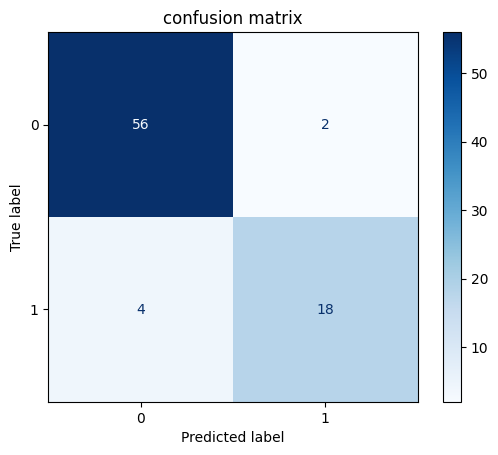

92.5
              precision    recall  f1-score   support

           0       0.93      0.97      0.95        58
           1       0.90      0.82      0.86        22

    accuracy                           0.93        80
   macro avg       0.92      0.89      0.90        80
weighted avg       0.92      0.93      0.92        80



In [11]:
from sklearn.metrics import confusion_matrix,accuracy_score,ConfusionMatrixDisplay,classification_report
cm=confusion_matrix(y_test,y_pred)
print(cm)

disp=ConfusionMatrixDisplay(cm)
disp.plot(cmap="Blues")
plt.title("confusion matrix")
plt.show()

acc=accuracy_score(y_test,y_pred)*100
print(acc)
print(classification_report(y_test,y_pred))
